# Data Understanding - MAD Dataset
Exploratory analysis for the AI Agent Evaluation Framework thesis.
Dataset: MAD_full_dataset.json (1242 traces, 7 frameworks, 14 MAST failure modes)

In [15]:
import importlib.util
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tiktoken

DATA_PATH = Path("../..") / "data" / "MAST-Data" / "MAD_full_dataset.json"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [16]:
with open(DATA_PATH) as f:
    raw = json.load(f)

df = pd.DataFrame([
    {
        "framework": d["mas_name"],
        "trace_id": d["trace_id"],
        "trace_key": d["trace"]["key"],
        "trajectory": d["trace"]["trajectory"],
        **{f"FM-{k}": v for k, v in d["mast_annotation"].items()},
    }
    for d in raw
])

FM_COLS = [c for c in df.columns if c.startswith("FM-")]
df["any_failure"] = df[FM_COLS].max(axis=1).astype(bool)

print(f"{len(df):,} traces | {df['framework'].nunique()} frameworks")
df.head(2)

1,242 traces | 7 frameworks


,framework,trace_id,trace_key,trajectory,FM-1.1,FM-1.2,FM-1.3,FM-1.4,FM-1.5,FM-2.1,FM-2.2,FM-2.3,FM-2.4,FM-2.5,FM-2.6,FM-3.1,FM-3.2,FM-3.3,any_failure
0,ChatDev,0,ChatDev_ProgramDev_GPT4o,[2025-31-03 19:09:41 INFO] **[Preprocessing]**...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False
1,ChatDev,1,ChatDev_ProgramDev_GPT4o,[2025-31-03 19:30:18 INFO] **[Preprocessing]**...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False


## 1. Traces per framework & success / failure rate

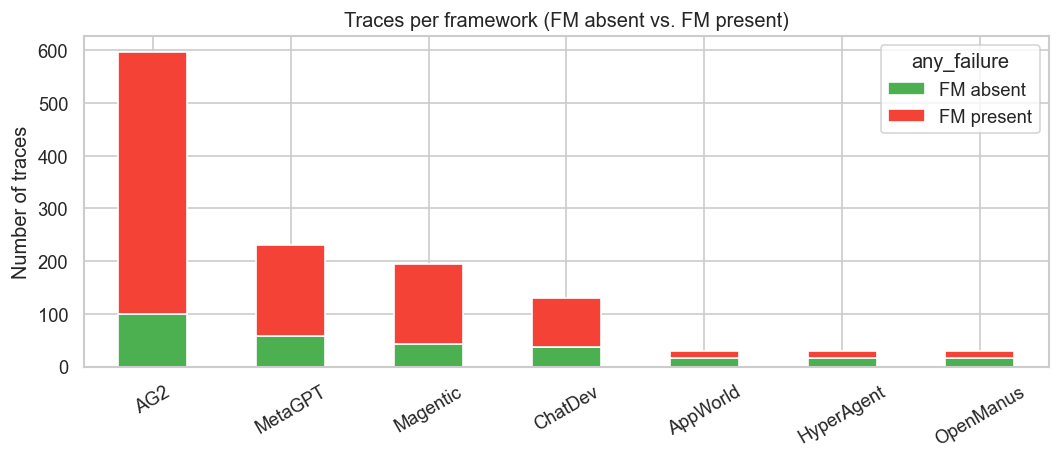

In [17]:
counts = (
    df.groupby(["framework", "any_failure"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "FM absent", True: "FM present"})
)
counts = counts.sort_values("FM present", ascending=False)

ax = counts.plot(kind="bar", stacked=True, figsize=(9, 4),
                 color=["#4CAF50", "#F44336"])
ax.set_title("Traces per framework (FM absent vs. FM present)")
ax.set_xlabel("")
ax.set_ylabel("Number of traces")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig_traces_per_framework.png")
plt.show()

In [18]:
counts["total"] = counts.sum(axis=1)
counts["fm_present_pct"] = (counts["FM present"] / counts["total"] * 100).round(1)
print(counts.sort_values("total", ascending=False).to_string())
print()
print(f"Total traces: {len(df)}")
print(f"Overall FM-present: {df["any_failure"].sum()} / {len(df)} = {df["any_failure"].mean()*100:.1f}%")

any_failure  FM absent  FM present  total  fm_present_pct
framework                                                
AG2                100         497    597            83.2
MetaGPT             58         172    230            74.8
Magentic            43         152    195            77.9
ChatDev             37          93    130            71.5
AppWorld            16          14     30            46.7
HyperAgent          16          14     30            46.7
OpenManus           16          14     30            46.7

Total traces: 1242
Overall FM-present: 956 / 1242 = 77.0%


The dataset is heavily skewed: AG2 accounts for 597 traces (48% of the dataset), while AppWorld, HyperAgent, and OpenManus each contribute exactly 30. Overall, 956 of 1,242 traces (77.0%) contain at least one failure mode. The FM-present ratio is highest for AG2 (83.2%) and lowest for AppWorld, HyperAgent, and OpenManus (46.7% each).

## 2. Failure-mode prevalence

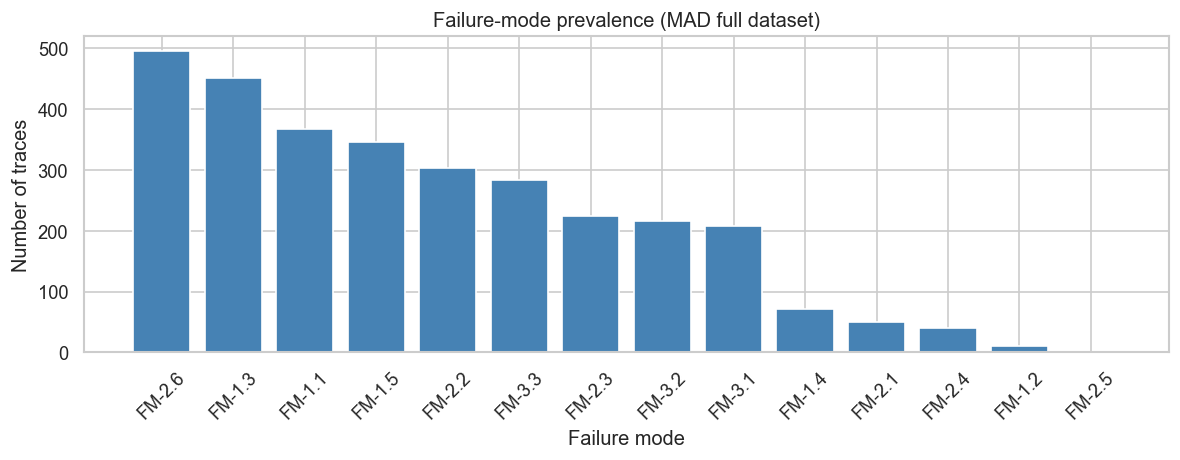

FM-2.6    495
FM-1.3    451
FM-1.1    367
FM-1.5    346
FM-2.2    303
FM-3.3    283
FM-2.3    224
FM-3.2    216
FM-3.1    208
FM-1.4     71
FM-2.1     50
FM-2.4     40
FM-1.2     10
FM-2.5      0


In [19]:
fm_counts = df[FM_COLS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fm_counts.index, fm_counts.values, color="steelblue")
ax.set_title("Failure-mode prevalence (MAD full dataset)")
ax.set_xlabel("Failure mode")
ax.set_ylabel("Number of traces")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("fig_fm_prevalence.png")
plt.show()

print(fm_counts.to_string())

FM-2.6 and FM-1.3 are by far the most prevalent failure modes, followed by FM-1.1, FM-1.5, and FM-2.2. FM-2.5 does not occur at all in the dataset, and FM-1.2 appears in only 10 traces. This strong imbalance means several failure modes will be difficult to evaluate reliably.

## 3. Failure-mode co-occurrence (heatmap)

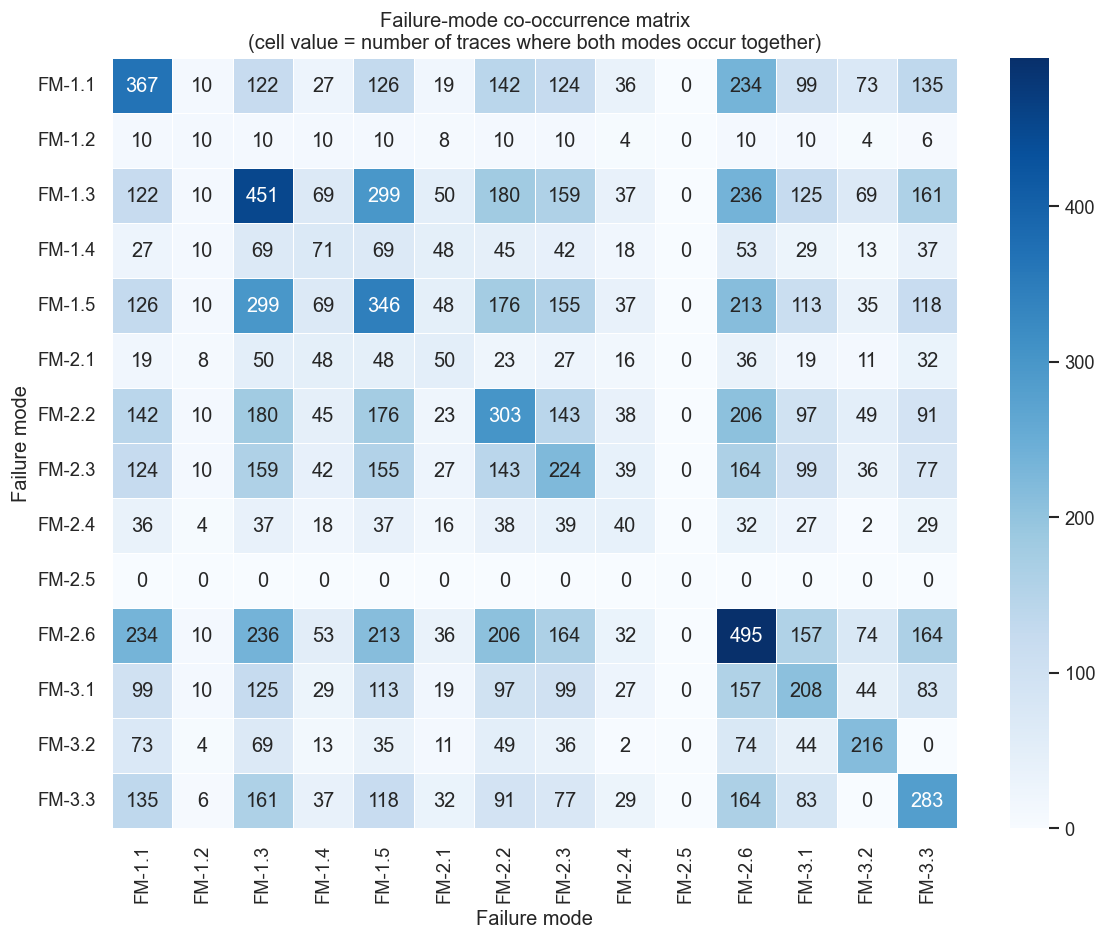

Diagonal (= how often each FM appears on its own):
FM-2.6    495
FM-1.3    451
FM-1.1    367
FM-1.5    346
FM-2.2    303
FM-3.3    283
FM-2.3    224
FM-3.2    216
FM-3.1    208
FM-1.4     71
FM-2.1     50
FM-2.4     40
FM-1.2     10
FM-2.5      0
dtype: int64


In [20]:
failed_traces = df.loc[df["any_failure"], FM_COLS]
cooccurrence = failed_traces.T.dot(failed_traces)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="Blues", linewidths=0.4, ax=ax)

ax.set_title("Failure-mode co-occurrence matrix\n(cell value = number of traces where both modes occur together)")
ax.set_xlabel("Failure mode")
ax.set_ylabel("Failure mode")
plt.tight_layout()
plt.savefig("fig_fm_cooccurrence.png")
plt.show()

print("Diagonal (= how often each FM appears on its own):")
print(pd.Series(cooccurrence.values.diagonal(), index=cooccurrence.index).sort_values(ascending=False))

FM-2.6 co-occurs strongly with most other failure modes, reflecting its high overall prevalence. FM-1.1, FM-1.3, and FM-1.5 also show frequent pairwise co-occurrence, suggesting they tend to appear together in the same traces. FM-2.1, FM-2.4 and FM-1.2 occur rarely and consequently show low co-occurrence counts across the board.

## 4. Trace Length Distributions (Tokens)

In [21]:
enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    return len(enc.encode(text))

print("Computing token counts...")
df["tokens"] = df["trajectory"].apply(count_tokens)
print("Done.")

df[["framework", "tokens"]].describe()

Computing token counts...
Done.


,tokens
count,1242.000000
mean,12076.438808
std,21242.802341
min,296.000000
25%,1115.250000
50%,1842.000000
75%,11769.750000
max,176380.000000


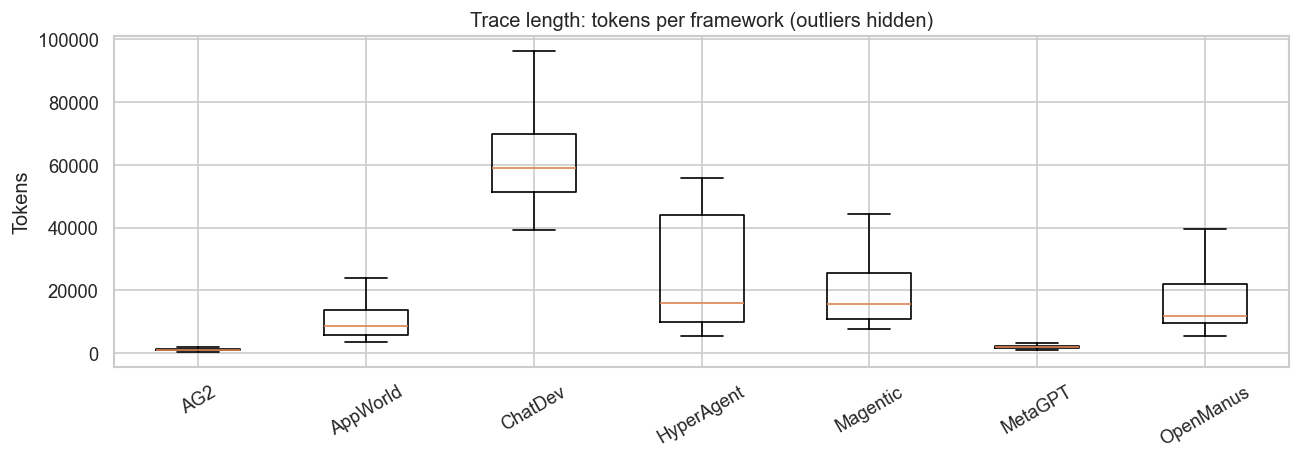

                min        q1   median        q3       max
framework                                                 
ChatDev     39284.0  51400.25  59031.0  69820.50   97561.0
HyperAgent   5314.0   9953.50  15930.0  44118.00  176380.0
Magentic     7783.0  10998.00  15531.0  25512.50   77952.0
OpenManus    5391.0   9731.75  11758.5  21929.25   39607.0
AppWorld     3554.0   5807.25   8707.5  13744.25   67492.0
MetaGPT       296.0   1658.25   1947.5   2258.00    7358.0
AG2           497.0    936.00   1110.0   1398.00    8286.0


In [22]:
frameworks = sorted(df["framework"].unique())

fig, ax = plt.subplots(figsize=(11, 4))

data_by_fw = [df.loc[df["framework"] == fw, "tokens"].values for fw in frameworks]
ax.boxplot(data_by_fw, tick_labels=frameworks, showfliers=False)
ax.set_title("Trace length: tokens per framework (outliers hidden)")
ax.set_ylabel("Tokens")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("fig_trace_length_distributions.png")
plt.show()

token_stats = df.groupby("framework")["tokens"].describe(percentiles=[.25, .5, .75])
token_stats = token_stats[["min", "25%", "50%", "75%", "max"]].rename(columns={"25%": "q1", "50%": "median", "75%": "q3"})
print(token_stats.sort_values("median", ascending=False).to_string())

ChatDev produces by far the longest traces (median ~59k tokens). HyperAgent and Magentic have similar medians (~16k), but HyperAgent has extreme outliers, the dataset maximum of 176k tokens belongs to HyperAgent. OpenManus sits at ~12k, AppWorld at ~9k, while MetaGPT and AG2 are much shorter (medians ~1k and ~2k respectively).

## 5. Step Length and Message-Kind Distribution per Framework

Uses the MAD-specific parsers to get the Step kinds (message, tool_call, tool_result, system) distribution over the frameworks. Two HyperAgent traces (trace_id 28 and 29) yield no parseable entries and are skipped, so this section covers 1 240 of the 1 242 dataset traces.

In [23]:
PARSERS_ROOT = (Path("../..") / 'parsers').resolve()
MAD_JSON = (Path("../..") / 'data' / 'MAST-Data' / 'MAD_full_dataset.json').resolve()
sys.path.insert(0, str(PARSERS_ROOT))

def _load_parser(name, rel_path):
    path = PARSERS_ROOT / rel_path
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_ag2        = _load_parser("p_ag2",        "ag2_parser/ag2_parser.py")
_appworld   = _load_parser("p_appworld",   "appworld_parser/appworld_parser.py")
_chatdev    = _load_parser("p_chatdev",    "chatdev_parser/chatdev_parser.py")
_hyperagent = _load_parser("p_hyperagent", "hyperagent_parser/hyperagent_parser.py")
_magentic   = _load_parser("p_magentic",   "magenticone_parser/magenticone_parser.py")
_metagpt    = _load_parser("p_metagpt",    "metagpt_parser/metagpt_parser.py")
_openmanus  = _load_parser("p_openmanus",  "openmanus_parser/openmanus_parser.py")

print("Parsing all frameworks...")
all_traces = (
    _ag2.parse_all(MAD_JSON)        +
    _appworld.parse_all(MAD_JSON)   +
    _chatdev.parse_all(MAD_JSON)    +
    _hyperagent.parse_all(MAD_JSON) +
    _magentic.parse_all(MAD_JSON)   +
    _metagpt.parse_all(MAD_JSON)    +
    _openmanus.parse_all(MAD_JSON)
)
n_fw = len({t.metadata['mas_name'] for t in all_traces})
print(f"Total parsed: {len(all_traces)} traces across {n_fw} frameworks")

Parsing all frameworks...
Total parsed: 1240 traces across 7 frameworks


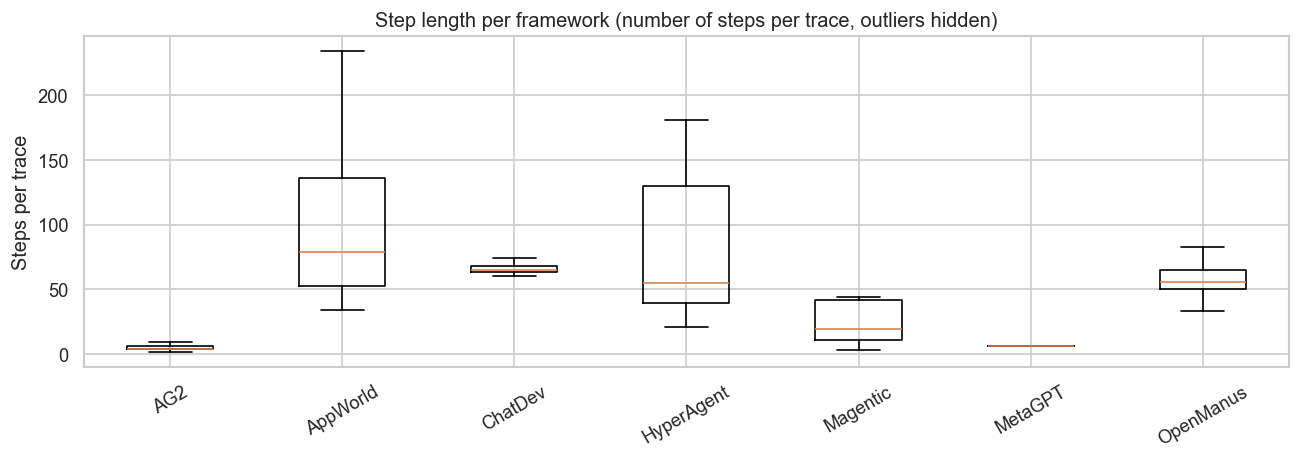


Median / mean / max steps per framework:
  AG2            : median=    4  mean=   5.2  max=28
  AppWorld       : median=   79  mean= 113.6  max=523
  ChatDev        : median=   65  mean=  67.2  max=104
  HyperAgent     : median=   55  mean= 111.1  max=536
  Magentic       : median=   19  mean=  24.9  max=44
  MetaGPT        : median=    6  mean=   6.0  max=6
  OpenManus      : median=   56  mean=  58.2  max=99


In [24]:
step_counts = {}
for t in all_traces:
    fw = t.metadata.get('mas_name', 'Unknown')
    step_counts.setdefault(fw, []).append(len(t.steps))

frameworks_ord = sorted(step_counts)

fig, ax = plt.subplots(figsize=(11, 4))
ax.boxplot([step_counts[fw] for fw in frameworks_ord], tick_labels=frameworks_ord, showfliers=False)
ax.set_title("Step length per framework (number of steps per trace, outliers hidden)")
ax.set_ylabel("Steps per trace")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig_step_length_per_framework.png")
plt.show()

print("\nMedian / mean / max steps per framework:")
for fw in frameworks_ord:
    arr = np.array(step_counts[fw])
    print(f"  {fw:15s}: median={np.median(arr):5.0f}  mean={np.mean(arr):6.1f}  max={arr.max()}")

AppWorld and Chatdev have the highest step counts per trace (median 79 and 65 respectively). AppWorld and HyperAgent are showing very high variance (max 523 and 536). AG2 and MetaGPT operate in far fewer steps (median 4 and 6), with MetaGPT being noticeably consistent (median/mean/max 6). 

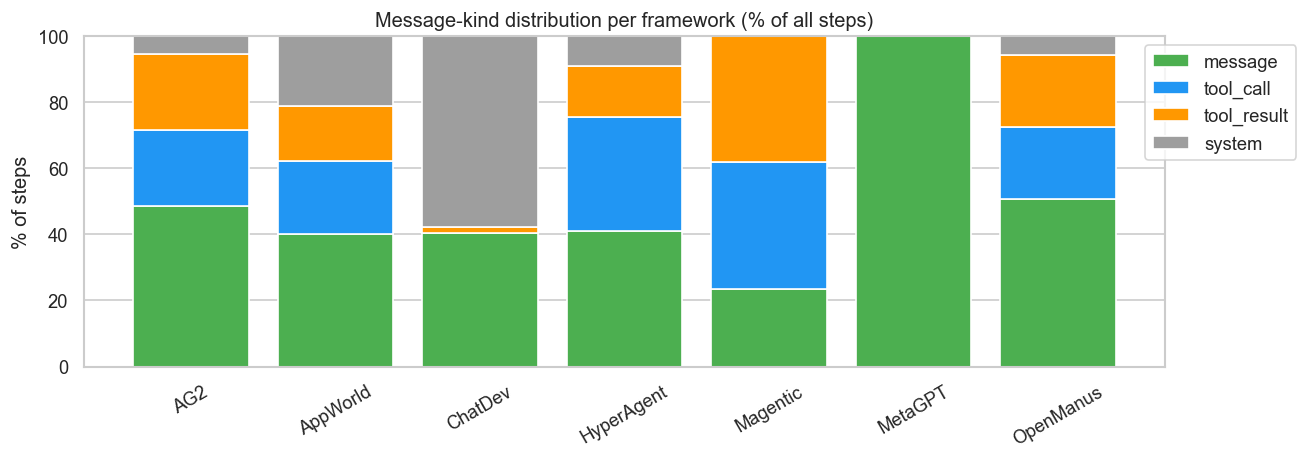


Raw step counts per framework and kind:
            message  tool_call  tool_result  system
AG2            1506        717          717     168
AppWorld       1366        755          563     724
ChatDev        3526          0          174    5033
HyperAgent     1278       1069          481     283
Magentic       1142       1862         1849       0
MetaGPT        1374          0            0       0
OpenManus       886        379          379     101


In [25]:
KINDS = ['message', 'tool_call', 'tool_result', 'system']
COLORS = ['#4CAF50', '#2196F3', '#FF9800', '#9E9E9E']

kind_counts = {fw: Counter() for fw in frameworks_ord}
for t in all_traces:
    fw = t.metadata.get('mas_name', 'Unknown')
    for s in t.steps:
        kind_counts[fw][s.kind] += 1

kind_df = pd.DataFrame(
    {fw: {k: kind_counts[fw].get(k, 0) for k in KINDS} for fw in frameworks_ord}
).T
kind_pct = kind_df.div(kind_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 4))
bottom = np.zeros(len(frameworks_ord))
for kind, color in zip(KINDS, COLORS):
    vals = kind_pct[kind].values
    ax.bar(frameworks_ord, vals, bottom=bottom, label=kind, color=color)
    bottom += vals

ax.set_title("Message-kind distribution per framework (% of all steps)")
ax.set_ylabel("% of steps")
ax.tick_params(axis="x", rotation=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.13, 1))
plt.tight_layout()
plt.savefig("fig_message_kind_distribution.png")
plt.show()

print("\nRaw step counts per framework and kind:")
print(kind_df.to_string())

The step-kind distribution reveals structural differences in how frameworks log their traces. MetaGPT shows no tool_calls or tool_results, agents only exchange messages, reflecting that the format logs LLM outputs only. ChatDev contains no tool_call steps, but does include tool_results, because tool_calls are not logged explicitly in the traces. 